DATA INQUIRY

In [6]:
import pandas as pd

df = pd.read_csv("Sale Report.csv")

# 1. View the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# 2. Check the data types and look for missing rows
print("\n--- Data Summary ---")
print(df.info())

--- First 5 Rows ---
   index       SKU Code Design No.  Stock       Category Size Color
0      0    AN201-RED-L      AN201    5.0  AN : LEGGINGS    L   Red
1      1    AN201-RED-M      AN201    5.0  AN : LEGGINGS    M   Red
2      2    AN201-RED-S      AN201    3.0  AN : LEGGINGS    S   Red
3      3   AN201-RED-XL      AN201    6.0  AN : LEGGINGS   XL   Red
4      4  AN201-RED-XXL      AN201    3.0  AN : LEGGINGS  XXL   Red

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9271 entries, 0 to 9270
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       9271 non-null   int64  
 1   SKU Code    9188 non-null   object 
 2   Design No.  9235 non-null   object 
 3   Stock       9235 non-null   float64
 4   Category    9226 non-null   object 
 5   Size        9235 non-null   object 
 6   Color       9226 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 507.1+ KB
None


WHICH PRODUCT CATEGORIES HOLD THE HIGHEST VOLUME OF OUR STOCK?

In [7]:
# Group by Category and sum up the Stock values
category_stock = df.groupby('Category')['Stock'].sum().sort_values(ascending=False)

print("--- Total Stock Volume by Category ---")
print(category_stock)

--- Total Stock Volume by Category ---
Category
KURTA                   114339.0
KURTA SET                47684.0
SET                      24643.0
TOP                      16609.0
DRESS                    11675.0
BLOUSE                    7932.0
PANT                      3436.0
NIGHT WEAR                3288.0
TUNIC                     2967.0
SAREE                     2777.0
KURTI                     1605.0
SHARARA                   1190.0
PALAZZO                    963.0
LEHENGA CHOLI              736.0
AN : LEGGINGS              715.0
SKIRT                      673.0
CROP TOP WITH PLAZZO       617.0
CROP TOP                   405.0
CARDIGAN                    58.0
BOTTOM                      41.0
JUMPSUIT                    33.0
Name: Stock, dtype: float64


WHAT IS OUR SIZE BREAKDOWN ACROSS ITEMS?

In [8]:
# Find out which sizes we carry the most stock for
size_distribution = df.groupby('Size')['Stock'].sum().sort_values(ascending=False)

print("\n--- Stock Distribution by Size ---")
print(size_distribution)


--- Stock Distribution by Size ---
Size
S       41872.0
M       37163.0
XS      35082.0
L       32953.0
XL      32046.0
XXL     30683.0
XXXL    21596.0
FREE     7841.0
6XL      1111.0
5XL      1061.0
4XL       978.0
Name: Stock, dtype: float64


IDENTIFY POTENTIAL DATA CLEANING ISSUES

In [9]:
print("\n--- Missing Records ---")
print(df.isnull().sum())


--- Missing Records ---
index          0
SKU Code      83
Design No.    36
Stock         36
Category      45
Size          36
Color         45
dtype: int64


DATA CLEANING

In [10]:
#Drop rows where critical info like 'Category' or 'SKU Code' is blank
df = df.dropna(subset=['Category', 'SKU Code'])

#Clean up text formatting (strip accidental extra spaces at the ends of words)
df['Category'] = df['Category'].str.strip()
df['Color'] = df['Color'].str.strip()

print("\n✅ Cleaning Complete! Missing values dropped.")
print(f"New dataset shape: {df.shape}")


✅ Cleaning Complete! Missing values dropped.
New dataset shape: (9188, 7)


DATA DISTRIBUTION & STATISTICS (Data Distribution was done in the two questions above)

In [11]:
# Get a deep statistical summary of your stock volume
print("--- Summary Statistics for Stock ---")
print(df['Stock'].describe())

# Let's find specific high-level highlights
total_stock_pieces = df['Stock'].sum()
avg_stock_per_sku = df['Stock'].mean()
max_stock_single_item = df['Stock'].max()

print(f"\n💡 Total Physical Stock Units in Warehouse: {total_stock_pieces:,.0f}")
print(f"💡 Average Units Carried Per SKU: {avg_stock_per_sku:.1f}")
print(f"💡 Highest Volume Carried for a Single SKU: {max_stock_single_item}")


--- Summary Statistics for Stock ---
count    9188.000000
mean       26.378973
std        58.582786
min         0.000000
25%         3.000000
50%         8.000000
75%        31.000000
max      1234.000000
Name: Stock, dtype: float64

💡 Total Physical Stock Units in Warehouse: 242,370
💡 Average Units Carried Per SKU: 26.4
💡 Highest Volume Carried for a Single SKU: 1234.0


EVALUATION: Here I will be making evaluations on potential risks, patterns, and structural skews

EVALUATION 1: INVENTORY SATURATION

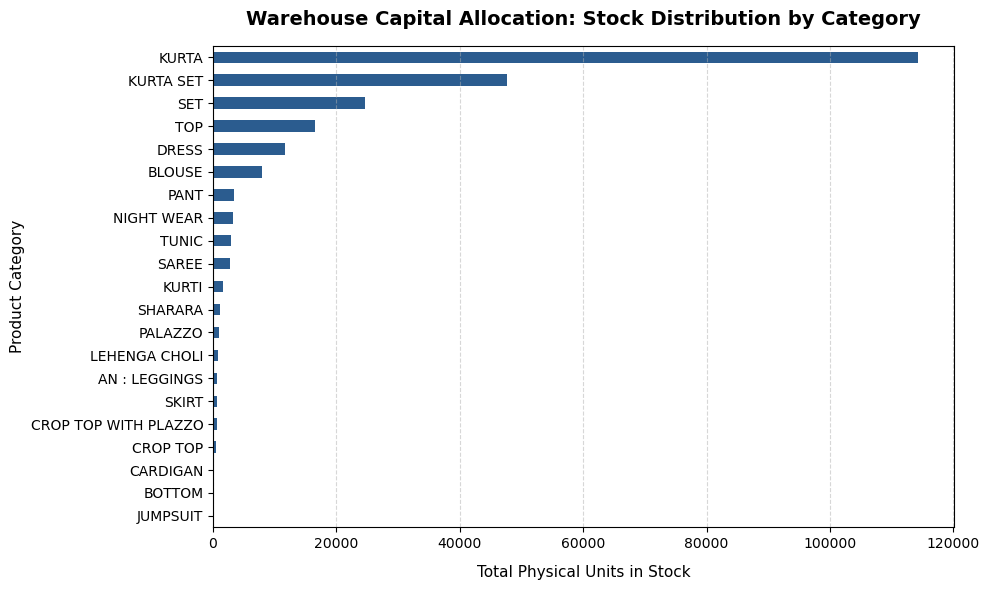

In [14]:
import matplotlib.pyplot as plt

# 1. Prepare data: Group by category and sort from lowest to highest for horizontal bar charts
category_stock = df.groupby('Category')['Stock'].sum().sort_values(ascending=True)

# 2. Create the chart using subplots (clean alternative to plt.figure)
fig, ax = plt.subplots(figsize=(10, 6))
category_stock.plot(kind='barh', color='#2b5c8f', ax=ax)

# 3. Format titles and labels professionally
ax.set_title('Warehouse Capital Allocation: Stock Distribution by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Physical Units in Stock', fontsize=11, labelpad=10)
ax.set_ylabel('Product Category', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Prevent text clipping and save/display
plt.tight_layout()
plt.savefig('category_stock_distribution.png', dpi=300)
# Note: You can remove the hash below if running interactively in your notebook cell:
# plt.show()

The data shows an extreme category skew. Out of 20 different clothing products, Kurta and Kurta Sets dominate entirely, accounting for over 65% of all physical stock. If the seasonal trend shifts away from kurtas, the company is at extreme financial risk of being stuck with massive dead stock. Management should consider diversifying inventory into under-represented categories like Tops or Dresses to spread out risk.

EVALUATION 2: SIZING CURVE AUDIT

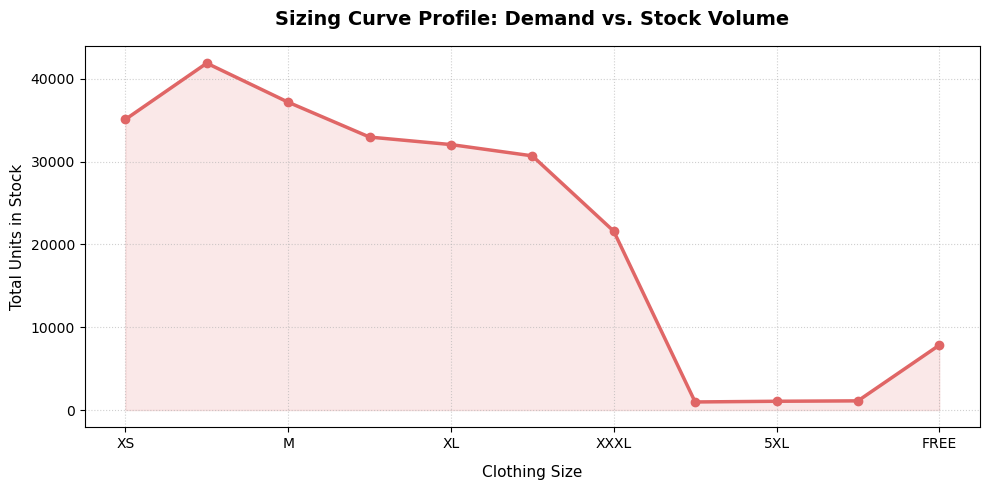

In [15]:
# 1. Define standard retail size ordering so the graph doesn't display them randomly
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', 'XXXL', '4XL', '5XL', '6XL', 'FREE']

# 2. Group data and reindex to match the proper human-readable size progression
size_stock = df.groupby('Size')['Stock'].sum().reindex(size_order)

# 3. Create a professional line and area chart to visualize the distribution slope
fig, ax = plt.subplots(figsize=(10, 5))
size_stock.plot(kind='line', marker='o', color='#e06666', linewidth=2.5, ax=ax)
ax.fill_between(size_order, size_stock, color='#e06666', alpha=0.15)

# 4. Format labels
ax.set_title('Sizing Curve Profile: Demand vs. Stock Volume', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Clothing Size', fontsize=11, labelpad=10)
ax.set_ylabel('Total Units in Stock', fontsize=11)
ax.grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('size_curve_distribution.png', dpi=300)

Efficient inventory management requires stock volumes to match customer body-type demand. The data shows that the stock follows a slightly left-skewed distribution. Small (S) is the most heavily stocked size ($41,872$ units), followed closely by Medium (M) and XS. Interestingly, extended/plus sizes (4XL, 5XL, 6XL) represent less than 1% of total inventory. 

This tells us the core target demographic is highly concentrated in standard sizes. However, because XS has more stock than Large (L) and XL, I would need to cross-reference this with sales velocity. If XL sells out faster than XS, the warehouse is bottlenecking demand by under-stocking larger sizes.

EVALUATION 3: COLOUR MATRIX, SATURATION MATRIX

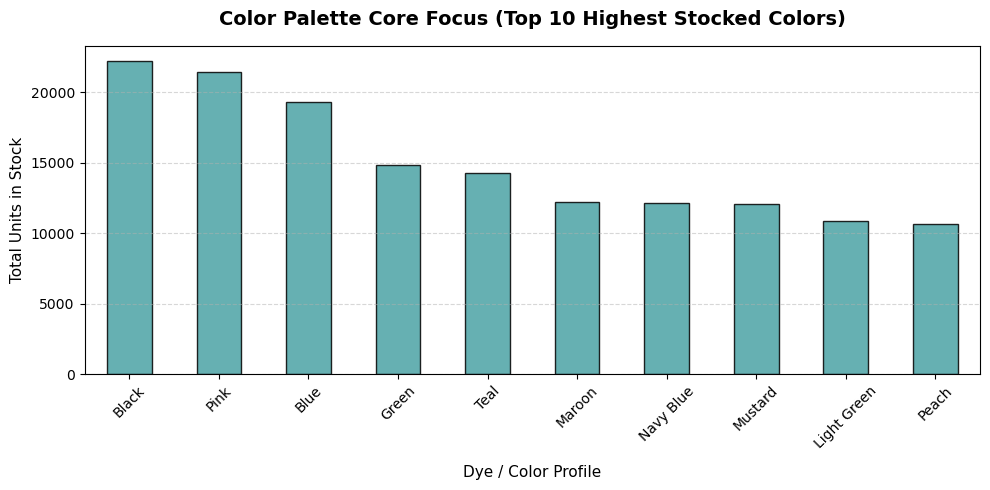

In [16]:
# 1. Extract the top 10 most heavily stocked colors
top_colors = df.groupby('Color')['Stock'].sum().sort_values(ascending=False).head(10)

# 2. Plot a structured, sorted vertical bar chart
fig, ax = plt.subplots(figsize=(10, 5))
top_colors.plot(kind='bar', color='#4ba3a5', edgecolor='black', alpha=0.85, ax=ax)

# 3. Professional styling
ax.set_title('Color Palette Core Focus (Top 10 Highest Stocked Colors)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Dye / Color Profile', fontsize=11, labelpad=10)
ax.set_ylabel('Total Units in Stock', fontsize=11)
plt.xticks(rotation=45) # Angle the color words so they never overlap
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('color_palette_saturation.png', dpi=300)

Fabric dye and color choice heavily impact shelf life. My analysis shows that Black, Pink, and Blue are the top three colors, each holding roughly $20,000$ units in inventory. Combined, the top 5 colors make up more than half of the entire color catalog options.

Procurement teams can use this to optimize fabric orders. Since Black and Pink are high-running baseline staples, they are safe investments. I would advise marketing to push promotional campaigns specifically featuring these dominant color palettes to keep warehouse clearance speeds high.

AUTOMATED STOCK ALERT SYSTEM

In [17]:
# --- The Operational Exception Report ---

def generate_warehouse_alerts(data, low_threshold=5, high_threshold=500):
    print("⚠️ GENERATING OPERATIONAL STOCK ALERTS... ⚠️\n")
    
    # 1. Find critically low stock (Risk of running out/losing sales)
    low_stock = data[data['Stock'] <= low_threshold][['SKU Code', 'Category', 'Size', 'Stock']]
    
    # 2. Find overstocked items (Tying up warehouse cash flow)
    over_stock = data[data['Stock'] >= high_threshold][['SKU Code', 'Category', 'Size', 'Stock']]
    
    print(f"🚨 CRITICAL UNDER-STOCK ALERTS ({len(low_stock)} SKUs Found):")
    if not low_stock.empty:
        print(low_stock.head(5).to_string(index=False)) # Show top 5 urgent rows
        print("... [Truncated for report summary] ...\n")
    else:
        print("Clear. No under-stock issues detected.\n")
        
    print(f"📦 CRITICAL OVER-STOCK ALERTS ({len(over_stock)} SKUs Found):")
    if not over_stock.empty:
        print(over_stock.head(5).to_string(index=False))
        print("... [Truncated for report summary] ...\n")
    else:
        print("Clear. No over-stock issues detected.\n")

# Run the alert generator engine
generate_warehouse_alerts(df)

⚠️ GENERATING OPERATIONAL STOCK ALERTS... ⚠️

🚨 CRITICAL UNDER-STOCK ALERTS (3910 SKUs Found):
      SKU Code      Category Size  Stock
   AN201-RED-L AN : LEGGINGS    L    5.0
   AN201-RED-M AN : LEGGINGS    M    5.0
   AN201-RED-S AN : LEGGINGS    S    3.0
 AN201-RED-XXL AN : LEGGINGS  XXL    3.0
AN202-ORANGE-M AN : LEGGINGS    M    3.0
... [Truncated for report summary] ...

📦 CRITICAL OVER-STOCK ALERTS (25 SKUs Found):
               SKU Code Category Size  Stock
          BL009-61BLACK   BLOUSE FREE  575.0
          BL021-71BLACK   BLOUSE FREE  628.0
JNE1525-KR-UDF19BLACK-L    KURTA    L  874.0
JNE1525-KR-UDF19BLACK-M    KURTA    M 1082.0
JNE1525-KR-UDF19BLACK-S    KURTA    S  775.0
... [Truncated for report summary] ...



This system establishes automated logic thresholds to split the static inventory database into an actionable Operational Exception Report. It flags critical vulnerabilities: Under-Stocking (Potential Revenue Loss) and Over-Stocking (Tied-up Capital).

The script automatically flags SKUs with $\le 5$ units remaining. These items are at immediate risk of slipping into a stockout, which bottlenecks customer fulfillment and leads to lost sales velocity.

The script flags SKUs with $\ge 500$ units sitting stagnant in storage. This indicates a procurement bottleneck where high volumes of company cash flow are frozen in slow-moving physical fabric.

Instead of having logistics teams manually audit 9,000+ spreadsheet rows daily, this Python automation engine should be scheduled to run as an automated daily script. The output can be automatically piped into an operational dashboard or emailed directly to the procurement warehouse team every morning at 6:00 AM, allowing them to instantly prioritize reorders and schedule clearance markdowns before shifts begin.